In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [2]:
## loading my dataset
df =pd.read_csv("PORTFOLIO.csv")

In [3]:
## Analyzing the basic information 
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          85000 non-null  object 
 1   track_name        84979 non-null  object 
 2   artist_name       85000 non-null  object 
 3   album_name        84954 non-null  object 
 4   release_date      85000 non-null  object 
 5   genre             85000 non-null  object 
 6   duration_ms       85000 non-null  int64  
 7   popularity        85000 non-null  int64  
 8   danceability      85000 non-null  float64
 9   energy            85000 non-null  float64
 10  key               85000 non-null  int64  
 11  loudness          85000 non-null  float64
 12  mode              85000 non-null  int64  
 13  instrumentalness  85000 non-null  float64
 14  tempo             85000 non-null  float64
 15  stream_count      85000 non-null  int64  
 16  country           85000 non-null  object

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,01-04-2016,Pop,234194,55,0.15,0.74,9,-32.22,0,0.436,73.12,13000,Brazil,0,Universal Music
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,15-04-2022,Metal,375706,45,0.44,0.46,0,-14.02,0,0.223,157.74,1000,France,1,Island Records
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,23-02-2016,Rock,289191,55,0.62,0.80,8,-48.26,1,0.584,71.03,1000,Germany,1,XL Recordings
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,12-10-2015,Pop,209484,51,0.78,0.98,1,-34.47,1,0.684,149.00,1000,France,0,Warner Music
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,08-07-2022,Indie,127435,39,0.74,0.18,10,-17.84,0,0.304,155.85,2000,United States,0,Independent


In [4]:
## Finding null values
df.isnull().sum()


track_id             0
track_name          21
artist_name          0
album_name          46
release_date         0
genre                0
duration_ms          0
popularity           0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
instrumentalness     0
tempo                0
stream_count         0
country              0
explicit             0
label                0
dtype: int64

In [5]:
# Handle missing text by imputing 'Unknown'
df['track_name'] = df['track_name'].fillna('Unknown Track')
df['album_name'] = df['album_name'].fillna('Unknown Album')


In [6]:
# Convert release_date to standard datetime format (handles DD-MM-YYYY)
df['release_date'] = pd.to_datetime(df['release_date'], format='%d-%m-%Y', errors='coerce')

In [7]:
# Convert explicit to boolean/string for easier filtering if needed, or keep as 0/1
df['explicit'] = df['explicit'].astype(int)



In [8]:
# Convert duration from milliseconds to minutes for more intuitive reporting
df['duration_mins'] = df['duration_ms'] / 60000


In [9]:
# Segment popularity into meaningful marketing tiers
bins = [0, 20, 40, 60, 80, 100]
labels = ['Niche', 'Emerging', 'Mainstream', 'Hit', 'Megahit']
df['popularity_tier'] = pd.cut(df['popularity'], bins=bins, labels=labels, include_lowest=True)



In [10]:
# Exploratory Data Analysis: Audio Feature Correlation
audio_features = ['danceability', 'energy', 'loudness', 'instrumentalness', 'tempo', 'popularity', 'stream_count']
correlation_matrix = df[audio_features].corr()


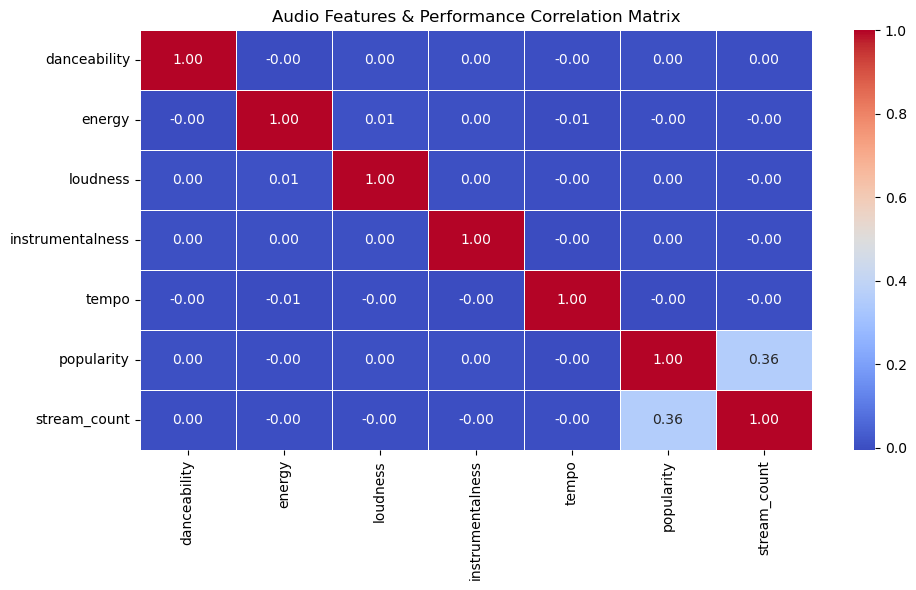

In [11]:
# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Audio Features & Performance Correlation Matrix')
plt.tight_layout()
plt.savefig('audio_feature_correlation.png')
plt.show()


In [12]:
df.to_csv("PORTFOLIO_CLEANED.csv", index=False)
print("Data cleaning complete. 'PORTFOLIO_CLEANED.csv' exported successfully.")

Data cleaning complete. 'PORTFOLIO_CLEANED.csv' exported successfully.
